<a href="https://colab.research.google.com/github/Prabhavathi2006/Data-Visualization/blob/main/Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [2]:
import os

print(os.listdir())

['.config', 'Life Expectancy Data.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("Life Expectancy Data.csv")

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


       Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0    6.0             

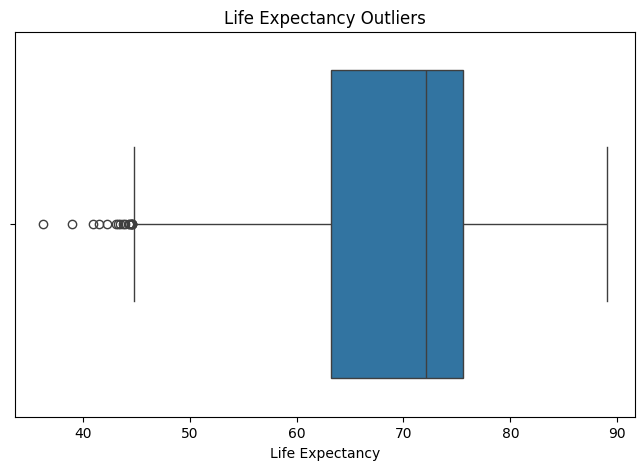


Normalized Life Expectancy
   Life expectancy
0         0.544592
1         0.447818
2         0.447818
3         0.440228
4         0.434535

Encoded Status
   Status
0       1
1       1
2       1
3       1
4       1

Encoded Country
   Country
0        0
1        0
2        0
3        0
4        0

Cleaned dataset saved successfully.

Final Dataset Shape : (2938, 22)

Final Missing Values:
Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP          

In [1]:
# ============================================================
# LIFE EXPECTANCY DATA - COMPLETE DATA PREPROCESSING
# ============================================================

# -----------------------------
# Import Libraries
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder


# -----------------------------
# Upload Dataset
# -----------------------------




# -----------------------------
# Load Dataset
# -----------------------------

# Change filename only if your uploaded file has a different name

df = pd.read_csv("Life Expectancy Data.csv")

# Remove unwanted spaces from column names

df.columns = df.columns.str.strip()

print(df.head())


# -----------------------------
# Dataset Shape and Information
# -----------------------------

print(df.shape)

df.info()


# -----------------------------
# Missing Values
# -----------------------------

print("Missing Values\n")

print(df.isnull().sum())


# -----------------------------
# Handle Missing Values
# -----------------------------

# Numeric columns

numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)


# Categorical columns

categorical_cols = df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


print("\nMissing Values After Handling\n")

print(df.isnull().sum())


# -----------------------------
# Duplicate Rows
# -----------------------------

print(
    "Duplicate Rows :",
    df.duplicated().sum()
)

df.drop_duplicates(
    inplace=True
)

print(
    "After Removal :",
    df.shape
)


# ============================================================
# OUTLIER DETECTION
# ============================================================


# -----------------------------
# Life Expectancy Outliers
# -----------------------------

Q1 = df["Life expectancy"].quantile(0.25)

Q3 = df["Life expectancy"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR


outliers = df[
    (df["Life expectancy"] < lower) |
    (df["Life expectancy"] > upper)
]

print("\nLife Expectancy Outliers")

print(
    outliers.head()
)


# -----------------------------
# Boxplot
# -----------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Life expectancy"]
)

plt.title(
    "Life Expectancy Outliers"
)

plt.xlabel(
    "Life Expectancy"
)

plt.show()


# ============================================================
# NORMALIZATION
# ============================================================


# -----------------------------
# Min-Max Scaling
# -----------------------------

scaler = MinMaxScaler()

df[["Life expectancy"]] = scaler.fit_transform(
    df[["Life expectancy"]]
)

print(
    "\nNormalized Life Expectancy"
)

print(
    df[["Life expectancy"]].head()
)


# ============================================================
# LABEL ENCODING
# ============================================================


# -----------------------------
# Encode Status
# -----------------------------

encoder = LabelEncoder()

df["Status"] = encoder.fit_transform(
    df["Status"]
)

print(
    "\nEncoded Status"
)

print(
    df[["Status"]].head()
)


# -----------------------------
# Encode Country
# -----------------------------

country_encoder = LabelEncoder()

df["Country"] = country_encoder.fit_transform(
    df["Country"].astype(str)
)

print(
    "\nEncoded Country"
)

print(
    df[["Country"]].head()
)


# ============================================================
# SAVE CLEANED DATASET
# ============================================================


df.to_csv(
    "cleaned_life_expectancy.csv",
    index=False
)

print(
    "\nCleaned dataset saved successfully."
)


# -----------------------------
# Final Dataset Check
# -----------------------------

print(
    "\nFinal Dataset Shape :",
    df.shape
)

print(
    "\nFinal Missing Values:"
)

print(
    df.isnull().sum()
)